In [30]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor
import matplotlib.pyplot as plt

from own_implementation import BPTF as BPTF
import bptf

# Please run everything up to the first bptf fit
# Thereafter, run each following cell on their own

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [31]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Theta_DK_M = [torch.tensor(factor) for factor in Theta_DK_M]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Load data

In [ ]:
use_existing_data = True

# for the first bptf.fit:
# using seed 100 causes the assert delta >= 0 to trip
# but using seed 0 doesn't
# please swap between the 2 seeds to get the 2 different types of assertion errors in the other cells
rn.seed(100)
device = 'cuda'

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :12, :]
    data = torch.tensor(data.todense(), dtype=torch.float64, device=device)
else:
    data = generate(shp=(200, 200, 20, 12, 3), K=10)[1]
    data = torch.tensor(data, dtype=torch.float64, device=device)

# Building mask (base example)

In [33]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

# Fit model

In [34]:
n_components = 50
max_iter = 500
tol = 1e-10

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

ELBO = 12731116.700847955, change = 0.02236731404224324, time taken = 12.265390157699585:   0%|          | 2/500 [00:30<2:08:02, 15.43s/it]


KeyboardInterrupt: 

# Mask with last mode completely masked

ELBO = 2551642174.8867598, change = 9.779474235020293e-09, time taken = 1.563554048538208: 100%|██████████| 500/500 [13:06<00:00,  1.57s/it]  

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-106751577.52548625, 1925215399.5165966, 2419436147.9788084, 2535839693.856168, 2548272658.555659, 2550890254.5082765, 2551416055.6541114, 2551500266.78081, 2551514535.3966756, 2551522118.9458346, 2551527926.7401443, 2551532812.346713, 2551537105.848822, 2551540683.6284447, 2551543855.360474, 2551546574.697592, 2551549038.7574167, 2551551355.96315, 2551553553.3015714, 2551555528.2412567, 2551557470.1357327, 2551559399.6496944, 2551561094.1025996, 2551562695.812408, 2551565010.150958, 2551577287.835249, 2551595143.8178825, 2551602224.544843, 2551605362.955294, 2551606764.130015, 2551607701.5515075, 2551608481.133198, 2551609188.790213, 2551609848.805905, 2551610480.193522, 2551611083.089209, 2551611662.475133, 2551612223.989326, 2551612777.736665, 2551613344.472248, 2551613957.677793, 2551614583.075607, 2551615047.3415112, 2551615481.0045476, 2551615914.481662, 2551616361.8131475, 2551616856.

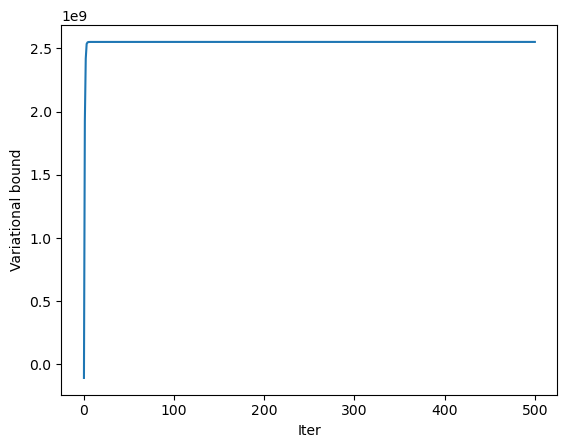

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 12, 3]), device='cuda',
     n_components=50)

In [ ]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, :] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Mask with the 1st and 3rd indices masked

ELBO = 2563972418.153312, change = 3.0143313786924452e-09, time taken = 1.584080696105957: 100%|██████████| 500/500 [13:10<00:00,  1.58s/it]  

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-159643704.16555947, 1946558272.651137, 2426417264.831089, 2553002413.128641, 2560688198.424, 2562686894.917338, 2563451789.867784, 2563867580.84961, 2563900866.631071, 2563911291.1527705, 2563916010.309589, 2563919365.037524, 2563922157.396439, 2563924748.4725943, 2563927134.091887, 2563929281.3057575, 2563931223.914588, 2563933038.1139545, 2563934528.4214067, 2563935799.90691, 2563936971.435705, 2563938058.2058387, 2563939079.1393337, 2563940044.481378, 2563940962.3308544, 2563941849.879173, 2563942729.437947, 2563943642.1485457, 2563944633.604245, 2563945506.33991, 2563946133.611065, 2563946693.5928273, 2563947228.3535943, 2563947737.413803, 2563948220.9992046, 2563948682.881474, 2563949125.7476273, 2563949549.3124533, 2563949954.2922974, 2563950345.519358, 2563950726.4503703, 2563951093.343792, 2563951448.548145, 2563951797.4651427, 2563952148.0417614, 2563952506.2300024, 2563952879.6666

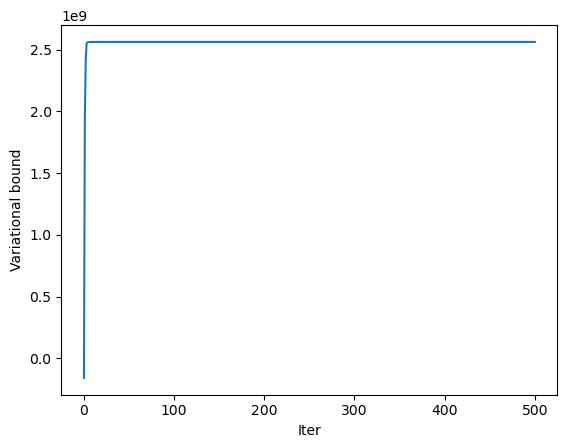

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 12, 3]), device='cuda',
     n_components=50)

In [ ]:
mask = np.ones(data.shape)
# april is set to missing
mask[:, :, :, 3, [0, 2]] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Mask with only diagonals masked

ELBO = 2595082564.1797633, change = 1.2877592397716825e-08, time taken = 7.019242763519287: 100%|██████████| 500/500 [30:19<00:00,  3.64s/it] 


Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-217407904.2851682, 1931700392.3748164, 2442228202.4985895, 2580701327.916619, 2591403619.227626, 2593464126.5387387, 2594360941.027386, 2594783945.508338, 2594943082.152148, 2594977058.953067, 2595001161.7022405, 2595013750.751573, 2595017961.371074, 2595021047.7520967, 2595023781.9159827, 2595026314.9305816, 2595028704.44679, 2595031045.3045034, 2595033123.8969445, 2595034831.209054, 2595036394.920953, 2595037834.4922733, 2595039172.5558877, 2595040422.4811506, 2595041591.561963, 2595042684.486725, 2595043705.750762, 2595044662.7858086, 2595045568.618321, 2595046443.7815948, 2595047260.5993443, 2595048030.58484, 2595048757.1896205, 2595049448.2773976, 2595050107.475959, 2595050734.0419917, 2595051331.983953, 2595051903.5536604, 2595052451.1791983, 2595052977.006172, 2595053482.5986004, 2595053969.2045407, 2595054436.379653, 2595054881.913601, 2595055310.105814, 2595055720.9306717, 25950561

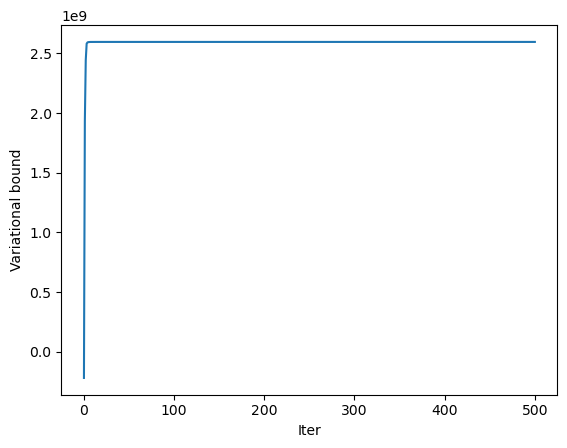

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 12, 3]), device='cuda',
     n_components=50)

In [ ]:
mask = np.ones(data.shape)

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# No mask

ELBO = 2604395589.614898, change = 2.2062267787194536e-09, time taken = 1.527184009552002: 100%|██████████| 500/500 [23:26<00:00,  2.81s/it]  

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-215257233.10072213, 1982556635.3760564, 2457946578.331456, 2586388242.216039, 2601609639.873942, 2604000396.9929996, 2604219727.1796947, 2604267104.3631034, 2604292434.733403, 2604303932.6849127, 2604310986.510932, 2604316317.6695642, 2604320812.175583, 2604324791.2059875, 2604328385.401569, 2604331682.15391, 2604334775.286279, 2604337768.793368, 2604340574.768407, 2604342976.2226305, 2604344982.2274184, 2604346811.013988, 2604348500.946725, 2604350071.3895464, 2604351535.9717975, 2604352902.8156433, 2604354179.622857, 2604355381.9303474, 2604356517.846917, 2604357589.9266706, 2604358606.7878084, 2604359584.699873, 2604360544.1683617, 2604361518.490822, 2604362495.928271, 2604363296.588742, 2604364014.3604174, 2604364691.5174603, 2604365336.764386, 2604365953.1228514, 2604366541.5419726, 2604367101.360885, 2604367637.997038, 2604368154.909678, 2604368653.594113, 2604369134.6401515, 26043695

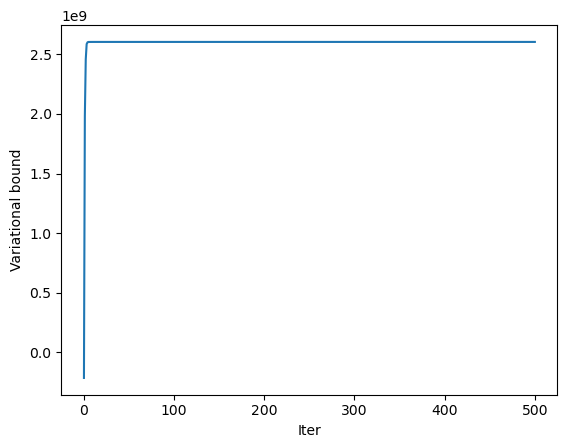

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 12, 3]), device='cuda',
     n_components=50)

In [ ]:
BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = None, max_iter = max_iter, verbose=True, tol=tol)